# Data Preprocessing

## Imports

In [27]:
from google.colab import drive
drive.mount('/content/drive')
#reading h5 files
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Handling
- Getting the keys
- Seeing the tabular features


In [28]:

with h5py.File('/content/drive/MyDrive/lhc_dataset/dataset/train/Copy of jetImage_1_30p_50000_60000.h5','r') as fo:
    print(list(fo.keys()))
    feature_names = [name.decode('utf-8') for name in fo['FeatureNames'][:]]
    jets_data = np.array(fo['jets_data'])
    jets_image = fo['jetImage']
    shape_image = jets_image.shape #tuple
    targets = fo['target']
    classes = len(np.unique(targets))

jets_df = pd.DataFrame(jets_data, columns=feature_names)
print(jets_data)
jets_df

['FeatureNames', 'jetImage', 'jets_data', 'target']
[[ 1.00000000e+00  1.03263110e+03  5.40035248e-01 ...  8.09326859e+01
   6.60724936e-06  3.40000000e+01]
 [ 1.00000000e+00  1.01125153e+03 -1.20615914e-01 ...  9.29416122e+01
   1.39665037e-01  3.20000000e+01]
 [ 1.00000000e+00  1.06862720e+03 -4.64241624e-01 ...  6.10299950e+01
   1.38953939e-01  6.60000000e+01]
 ...
 [ 1.00000000e+00  1.02876111e+03 -6.52325213e-01 ...  9.07221603e+01
   1.41261995e-01  3.60000000e+01]
 [ 1.00000000e+00  1.00533032e+03  1.05653539e-01 ...  8.38544769e+01
   3.81469727e-06  5.70000000e+01]
 [ 1.00000000e+00  1.02123602e+03  1.62193760e-01 ...  6.79164505e+01
   3.81469727e-06  4.50000000e+01]]


,j_ptfrac,j_pt,j_eta,j_mass,j_tau1_b1,j_tau2_b1,j_tau3_b1,j_tau1_b2,j_tau2_b2,j_tau3_b2,...,j_m2_b1_mmdt,j_m2_b2_mmdt,j_n2_b1_mmdt,j_n2_b2_mmdt,j_mass_trim,j_mass_mmdt,j_mass_prun,j_mass_sdb2,j_mass_sdm1,j_multiplicity
0,1.0,1032.631104,0.540035,88.771477,72.465576,16.148813,8.323047,6.342993,0.540440,0.253054,...,0.067383,0.019392,0.199340,0.054772,81.036026,80.932686,80.481415,80.932686,0.000007,34.0
1,1.0,1011.251526,-0.120616,93.720314,44.201790,10.182505,7.521371,8.033822,0.483455,0.362641,...,0.038602,0.006589,0.185059,0.036986,93.042679,92.941612,88.792862,92.941612,0.139665,32.0
2,1.0,1068.627197,-0.464242,61.029995,40.439556,29.455791,20.749588,3.088207,1.866474,0.949914,...,0.143574,0.082622,0.428307,0.316398,61.029995,53.493855,49.871414,61.029995,0.138954,66.0
3,1.0,1098.173340,-0.433919,85.518356,65.442268,11.877806,8.864352,6.446519,0.438201,0.297671,...,0.050815,0.013192,0.160477,0.034743,84.845108,84.845108,83.901581,84.845108,0.000008,38.0
4,1.0,1000.838562,-1.021529,173.566376,135.893677,75.558243,49.320866,29.050821,12.121775,5.297045,...,0.141295,0.086486,0.392651,0.273189,173.566376,172.945374,170.535461,172.945374,0.138472,102.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.0,935.801270,1.346551,127.426384,74.516541,14.720252,13.759643,17.064980,1.119493,0.927594,...,0.041857,0.011559,0.179040,0.054236,127.426384,127.426384,122.521812,127.426384,0.109019,55.0
9996,1.0,1068.437744,0.979943,93.238121,50.835464,9.843947,8.876306,7.955670,0.293017,0.274453,...,0.038441,0.006242,0.153322,0.025585,93.238121,93.238121,92.755386,93.238121,0.000005,33.0
9997,1.0,1028.761108,-0.652325,91.579903,43.144440,12.033950,9.300777,8.043329,0.642133,0.596786,...,0.042415,0.007959,0.198784,0.049174,90.722160,90.722160,87.751915,90.722160,0.141262,36.0
9998,1.0,1005.330322,0.105654,86.890800,60.840160,31.166147,15.422149,7.271711,2.165812,0.786109,...,0.092232,0.036294,0.286296,0.113623,84.969505,83.854477,83.448914,83.854477,0.000004,57.0


## Feature Handling
- Identifying missing values(if any) <br>

In [ ]:
#missing values
jets_df.isna().any().any() #no missing values
# df[df.isna().any(axis=1)] # to print only rows containing missing values

np.False_

In [ ]:
#checking sentinel values
print('Range of multiplicity: ', jets_df.j_multiplicity.min(),'-', jets_df.j_multiplicity.max())
print('Range of mass: ', jets_df.j_mass.min(),'-', jets_df.j_mass.max())
print('Range of Pt: ', jets_df.j_pt.min(),'-', jets_df.j_pt.max())

Range of multiplicity:  9.0 - 166.0
Range of mass:  8.143604278564453 - 436.6137390136719
Range of Pt:  422.2734680175781 - 2749.880615234375


Since we found no missing or sentinel values in the data, no imputation strategies were required. <br>
If some missing values had been identified, <b>Median Imputation</b> would have likely been the most suitable imputation strategy because it would preserve distribution robustness and avoid distortion of extreme values, unlike mean imputation. However, any imputation strategy must be carefully considered beforehand, as improper handling could result in misclassification of rare physics events.

## Tabular Data Preparation

### Covariance Matrix

In [35]:
data = pd.DataFrame(jets_df.select_dtypes(include=np.number).values)
X = np.array(data.loc[:, data.std() != 0]) #to remove columns from the table, which have variance=0; like j_ptfrac
X_mean = X.mean(axis = 0)
X_std = X.std(axis = 0)
X_scaled = X -X_mean/X_std
#Covariance Matrix
cov_mat = np.cov(X_scaled, rowvar = False)

#eigenvalues, eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_mat) #eigh is faster than eig.

sorted_index = np.argsort(eigenvalues)[::-1] #np.argsort sorts in ascending order, slicing changes it to descending(largest variance/eigenvalue first)
eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]
#now the first eigenvalue and eigenvector corresponds to the most significant component
print(cov_mat)
print('Eigen Values:', eigenvalues)
print('Eigen Vectors:', eigenvectors)

[[ 1.47642070e+04 -4.52568049e-02  4.68620766e+02 ...  3.75372783e+02
  -2.40397429e+02  4.19454892e+02]
 [-4.52568049e-02  5.80463921e-01  1.92396796e-01 ...  2.33292696e-01
  -2.65508385e-01  1.63769758e-02]
 [ 4.68620766e+02  1.92396796e-01  1.86596496e+03 ...  1.96700211e+03
   9.46145701e+02  5.87533595e+02]
 ...
 [ 3.75372783e+02  2.33292696e-01  1.96700211e+03 ...  2.09821550e+03
   9.79770573e+02  6.06164120e+02]
 [-2.40397429e+02 -2.65508385e-01  9.46145701e+02 ...  9.79770573e+02
   1.79116438e+03  2.67025544e+02]
 [ 4.19454892e+02  1.63769758e-02  5.87533595e+02 ...  6.06164120e+02
   2.67025544e+02  4.76217534e+02]]
Eigen Values: [1.68274803e+04 1.47272087e+04 1.31003876e+03 6.77435389e+02
 4.68781602e+02 2.87290920e+02 1.68771840e+02 1.04571058e+02
 3.51069168e+01 3.02148362e+01 2.00001712e+01 1.03943552e+01
 9.51500691e+00 4.75918942e+00 3.54558989e+00 1.54073280e+00
 1.23367411e+00 7.18131412e-01 5.79366985e-01 3.68905715e-01
 2.08687935e-01 1.77388442e-01 6.68300446e-02

### Explained Variance Ratio

In [36]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
pca = PCA()
pca.fit(data_scaled)

PCA()

In [38]:
#Explained Variance Ratio
e_v_r = pd.DataFrame(pca.explained_variance_ratio_)
e_v_r

,0
0,4.464479e-01
1,2.254054e-01
2,8.192377e-02
3,4.237189e-02
4,3.649157e-02
5,2.321348e-02
6,2.201143e-02
7,1.919776e-02
8,1.811628e-02
9,1.674359e-02


### Scree Plot

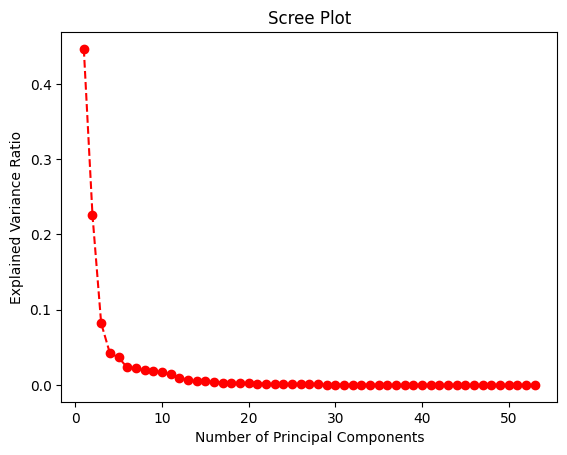

In [32]:
plt.plot(range(1,len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, 'o--r')
plt.title('Scree Plot')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.show()

### Additional: Cumulative Explained Variance

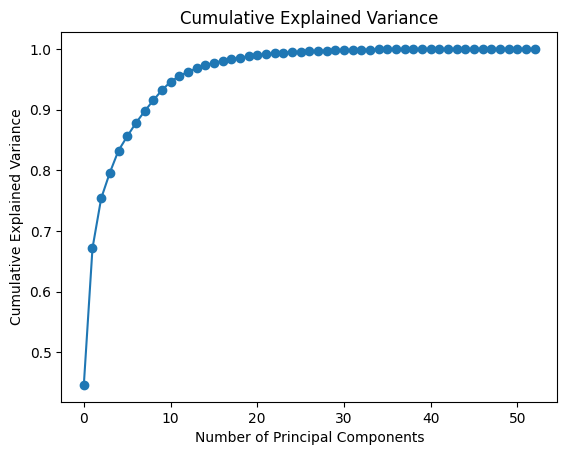

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

## Dataset Summary

In [ ]:
print('Number of Rows:', len(jets_df))
print('Number of Columns:', len(list(jets_df.columns)))
print('Number of Images:', shape_image[0])
print('Image Size:{}X{}'.format(shape_image[1], shape_image[2]))
print('Number of distinct targets:', classes)

Number of Rows: 10000
Number of Columns: 53
Number of Images: 10000
Image Size:100X100
Number of distinct targets: 5


In [ ]:
kinematic_features = ['j_pt', 'j_eta', 'j_mass', 'j_mass_trim', 'j_mass_mmdt', 'j_mass_prun', 'j_mass_sdb2', 'j_mass_sdm1']
substructure_features = ['j_tau1_b1', 'j_tau2_b1', 'j_tau32_b1']
energy_features = ['j_c1_b1', 'j_c2_b1', 'j_d2_b1']

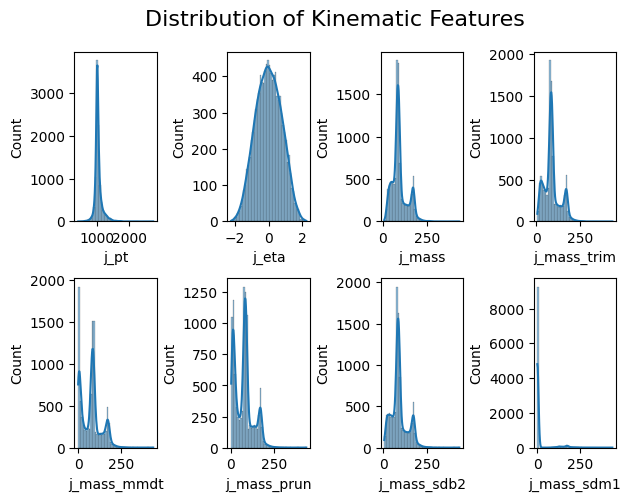

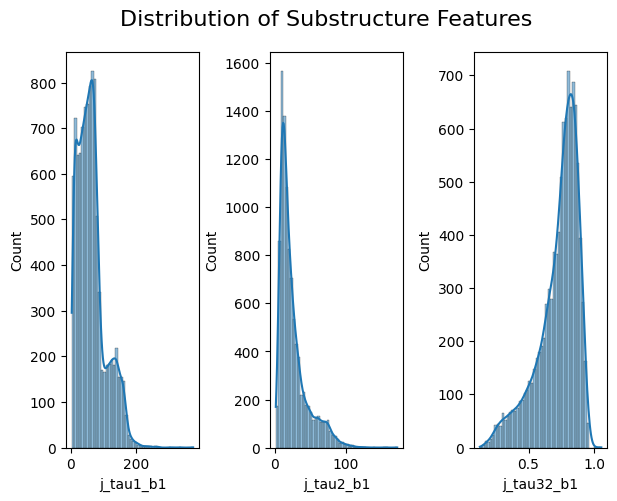

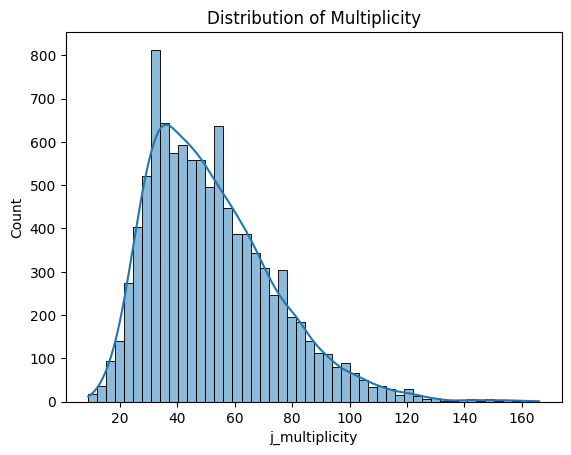

In [39]:
fig, axes = plt.subplots(2,4)
plt.tight_layout(pad = 2)
for i,feature in enumerate(kinematic_features):
    if i<4:
        sns.histplot(jets_df[feature], bins = 50, kde = True, ax = axes[0,i])
    else:
        sns.histplot(jets_df[feature], bins = 50, kde = True, ax = axes[1,i-4])
fig.suptitle("Distribution of Kinematic Features", fontsize=16, y=1.02)
plt.show()

fig, axes = plt.subplots(1,3)
plt.tight_layout(pad = 2)
for i,feature in enumerate(substructure_features):
        sns.histplot(jets_df[feature], bins = 50, kde = True, ax = axes[i])
fig.suptitle("Distribution of Substructure Features", fontsize=16, y=1.02)
plt.show()

sns.histplot(jets_df['j_multiplicity'], bins = 50, kde = True)
plt.title('Distribution of Multiplicity')
plt.show()